# Data Mining Analysis of Conversion Patterns in Digital Marketing Campaigns

**Objective.** Identify the customer behaviors and campaign characteristics that drive conversions in a digital marketing dataset.

**Dataset.** 8,000 customer records with 20 attributes covering demographics, marketing-specific variables, customer engagement, historical data, and a binary conversion target. Source: Kaggle - Predict Conversion in Digital Marketing Dataset.

**Methods used in this notebook:**
1. Data loading and cleaning
2. Descriptive statistics and exploratory data analysis (EDA)
3. Target variable (Conversion) analysis
4. Predictive models: Logistic Regression, Decision Tree, Random Forest
5. Apriori association rule mining

## 1. Setup

In [1]:
import os
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42

## 2. Load and Inspect the Data

In [2]:
df = pd.read_csv('../data/digital_marketing_campaign.csv')

# Drop columns that are not useful for analysis:
# - CustomerID is just an identifier
# - AdvertisingPlatform and AdvertisingTool are confidential (single value each)
df = df.drop(columns=['CustomerID', 'AdvertisingPlatform', 'AdvertisingTool'])

print(f'Shape: {df.shape}')
df.head()

Shape: (8000, 17)


,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
0,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,1
1,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,1
2,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,1
3,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,1
4,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,1


In [3]:
# Check for duplicates and missing values
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Total missing values: {df.isnull().sum().sum()}')
print()
df.info()

Duplicate rows: 0
Total missing values: 0

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                8000 non-null   int64  
 1   Gender             8000 non-null   str    
 2   Income             8000 non-null   int64  
 3   CampaignChannel    8000 non-null   str    
 4   CampaignType       8000 non-null   str    
 5   AdSpend            8000 non-null   float64
 6   ClickThroughRate   8000 non-null   float64
 7   ConversionRate     8000 non-null   float64
 8   WebsiteVisits      8000 non-null   int64  
 9   PagesPerVisit      8000 non-null   float64
 10  TimeOnSite         8000 non-null   float64
 11  SocialShares       8000 non-null   int64  
 12  EmailOpens         8000 non-null   int64  
 13  EmailClicks        8000 non-null   int64  
 14  PreviousPurchases  8000 non-null   int64  
 15  LoyaltyPoints      8000 non-null   int64

The dataset is clean: no duplicates and no missing values. We can proceed directly to analysis.

## 3. Descriptive Statistics

In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
stats = df[numeric_cols].describe().T
stats['median'] = df[numeric_cols].median()
stats = stats[['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']]
stats.round(2)

,count,mean,median,std,min,25%,50%,75%,max
Age,8000.0,43.63,43.00,14.90,18.00,31.00,43.00,56.00,69.00
Income,8000.0,84664.20,84926.50,37580.39,20014.00,51744.50,84926.50,116815.75,149986.00
AdSpend,8000.0,5000.94,5013.44,2838.04,100.05,2523.22,5013.44,7407.99,9997.91
ClickThroughRate,8000.0,0.15,0.15,0.08,0.01,0.08,0.15,0.23,0.30
ConversionRate,8000.0,0.10,0.10,0.05,0.01,0.06,0.10,0.15,0.20
WebsiteVisits,8000.0,24.75,25.00,14.31,0.00,13.00,25.00,37.00,49.00
PagesPerVisit,8000.0,5.55,5.53,2.61,1.00,3.30,5.53,7.84,10.00
TimeOnSite,8000.0,7.73,7.68,4.23,0.50,4.07,7.68,11.48,15.00
SocialShares,8000.0,49.80,50.00,28.90,0.00,25.00,50.00,75.00,99.00
EmailOpens,8000.0,9.48,9.00,5.71,0.00,5.00,9.00,14.00,19.00


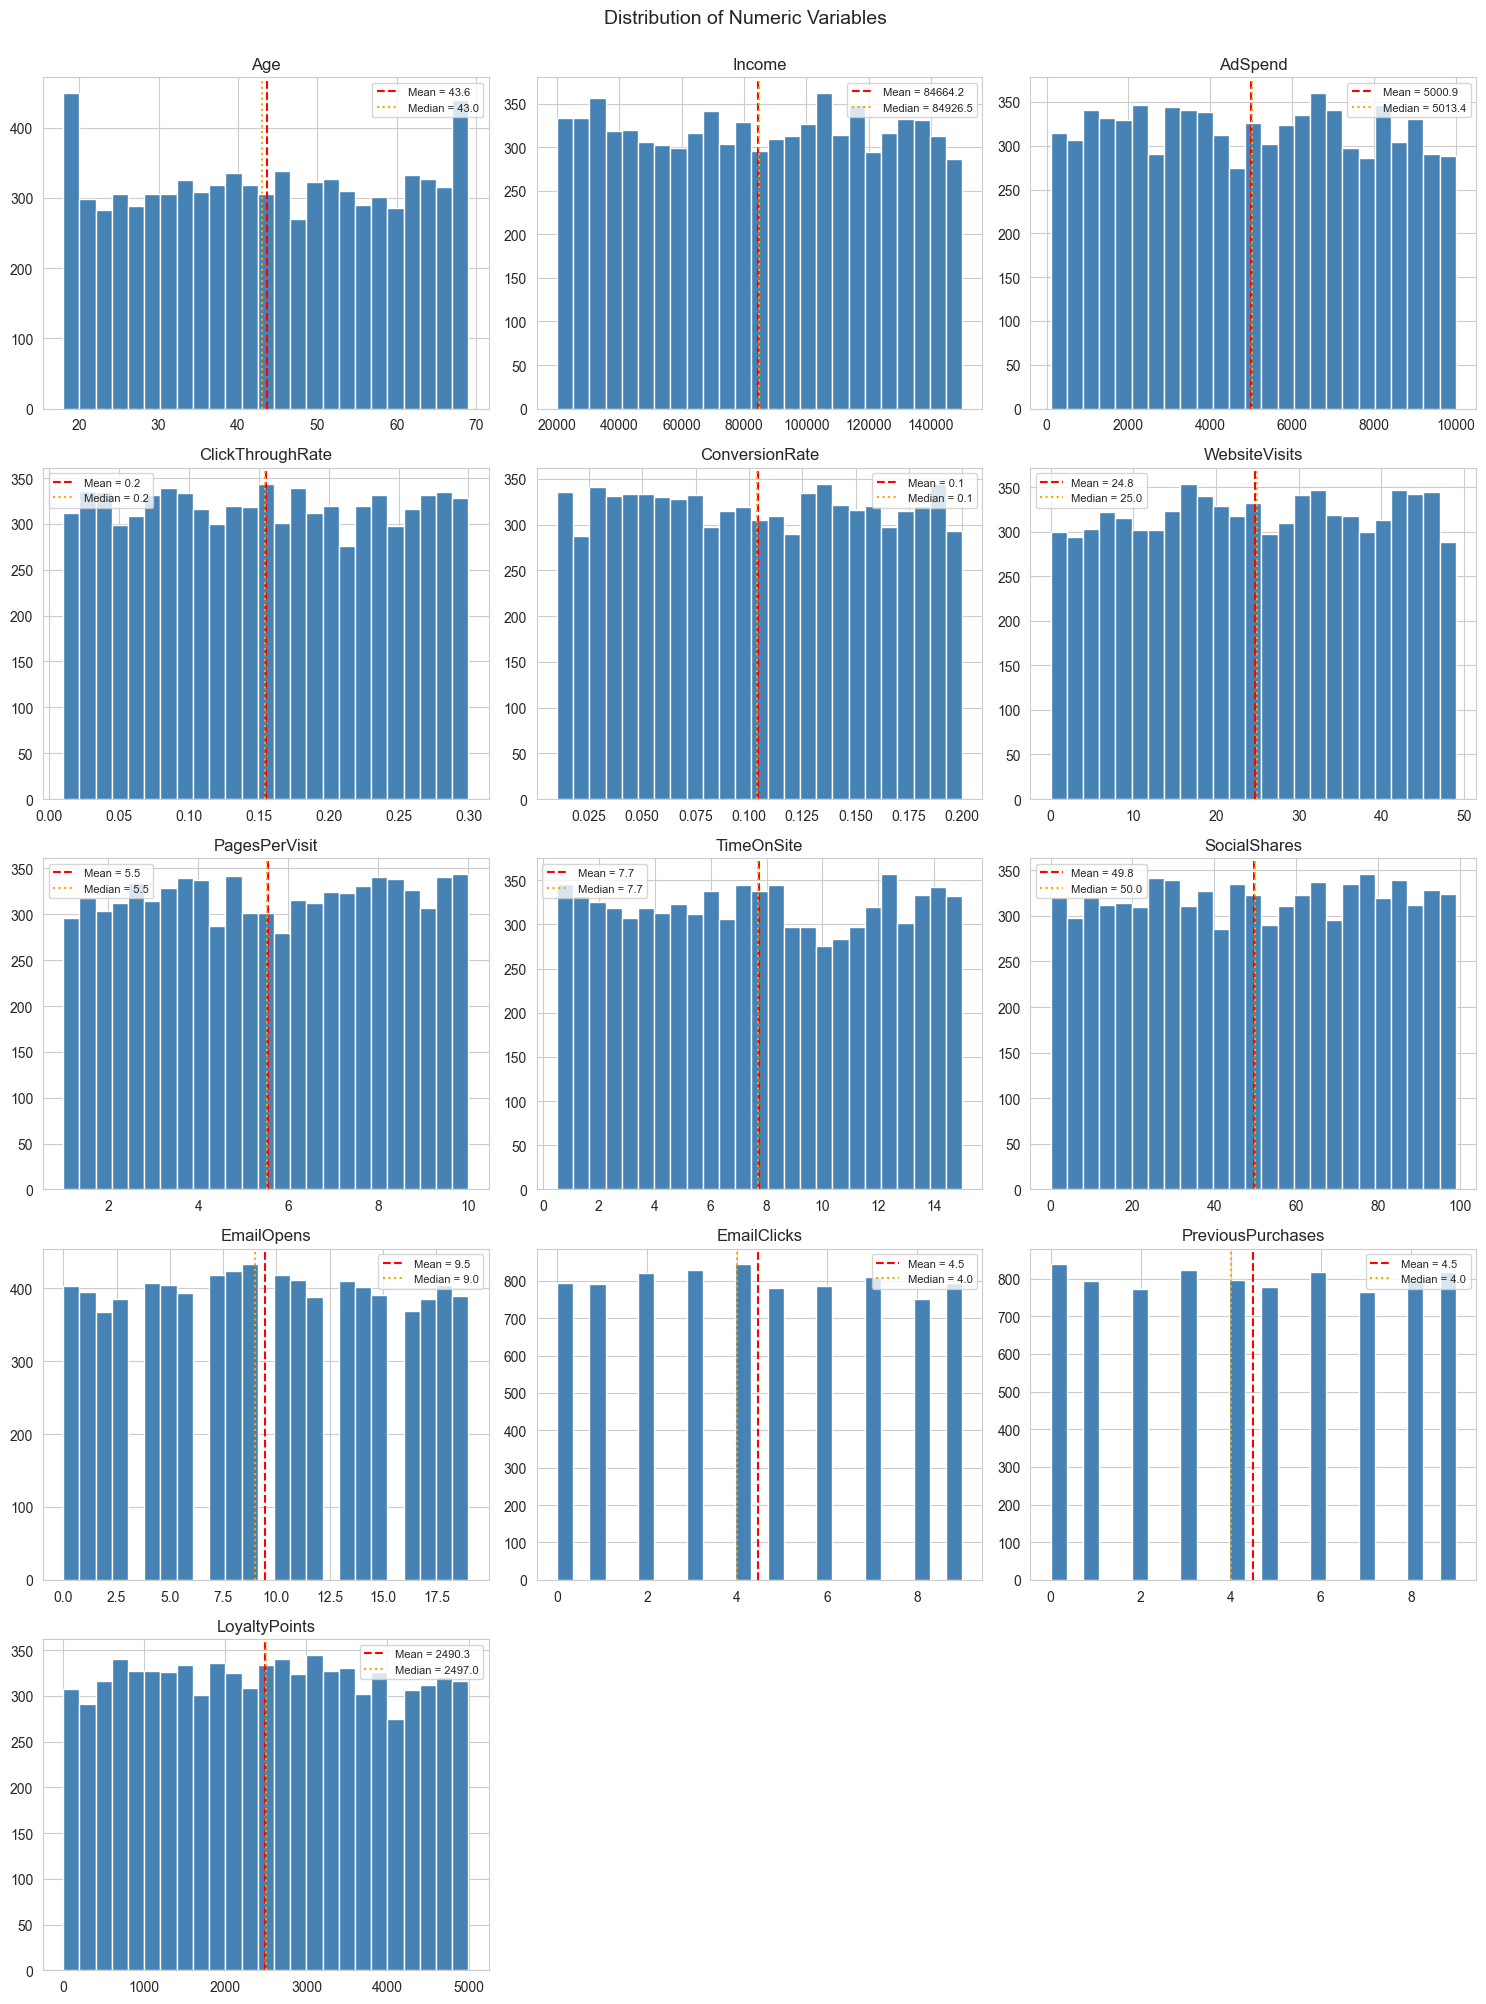

In [5]:
# Distribution of numeric variables
numeric_to_plot = [c for c in numeric_cols if c != 'Conversion']
n_cols = 3
n_rows = (len(numeric_to_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_to_plot):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--',
                    label=f'Mean = {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle=':',
                    label=f'Median = {df[col].median():.1f}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(len(numeric_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numeric Variables', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

Most numeric features are roughly uniform across their range. Mean and median sit very close to each other for nearly every variable, suggesting no heavy skew or extreme outliers.

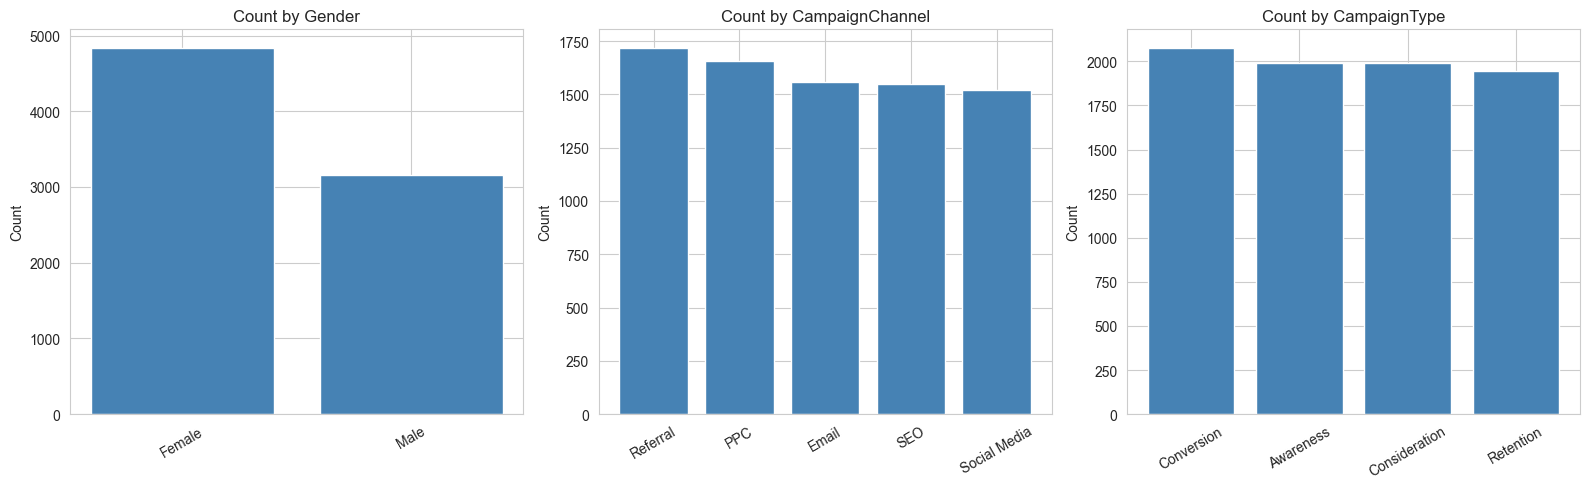

In [6]:
# Distribution of categorical variables
cat_cols = ['Gender', 'CampaignChannel', 'CampaignType']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    ax.set_title(f'Count by {col}')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. Target Variable: Conversion

The goal is to understand what drives the binary `Conversion` outcome.

In [7]:
counts = df['Conversion'].value_counts()
total = len(df)
print(f'Converted (1):     {counts[1]} ({counts[1] / total * 100:.1f}%)')
print(f'Not converted (0): {counts[0]} ({counts[0] / total * 100:.1f}%)')

# Conversion rate by each categorical variable
for col in ['Gender', 'CampaignChannel', 'CampaignType']:
    rates = df.groupby(col)['Conversion'].mean() * 100
    print(f'\nConversion rate by {col}:')
    print(rates.round(2).to_string())

Converted (1):     7012 (87.6%)
Not converted (0): 988 (12.3%)

Conversion rate by Gender:
Gender
Female    87.62
Male      87.69

Conversion rate by CampaignChannel:
CampaignChannel
Email           87.03
PPC             88.28
Referral        88.31
SEO             87.68
Social Media    86.83

Conversion rate by CampaignType:
CampaignType
Awareness        85.56
Consideration    85.56
Conversion       93.36
Retention        85.82


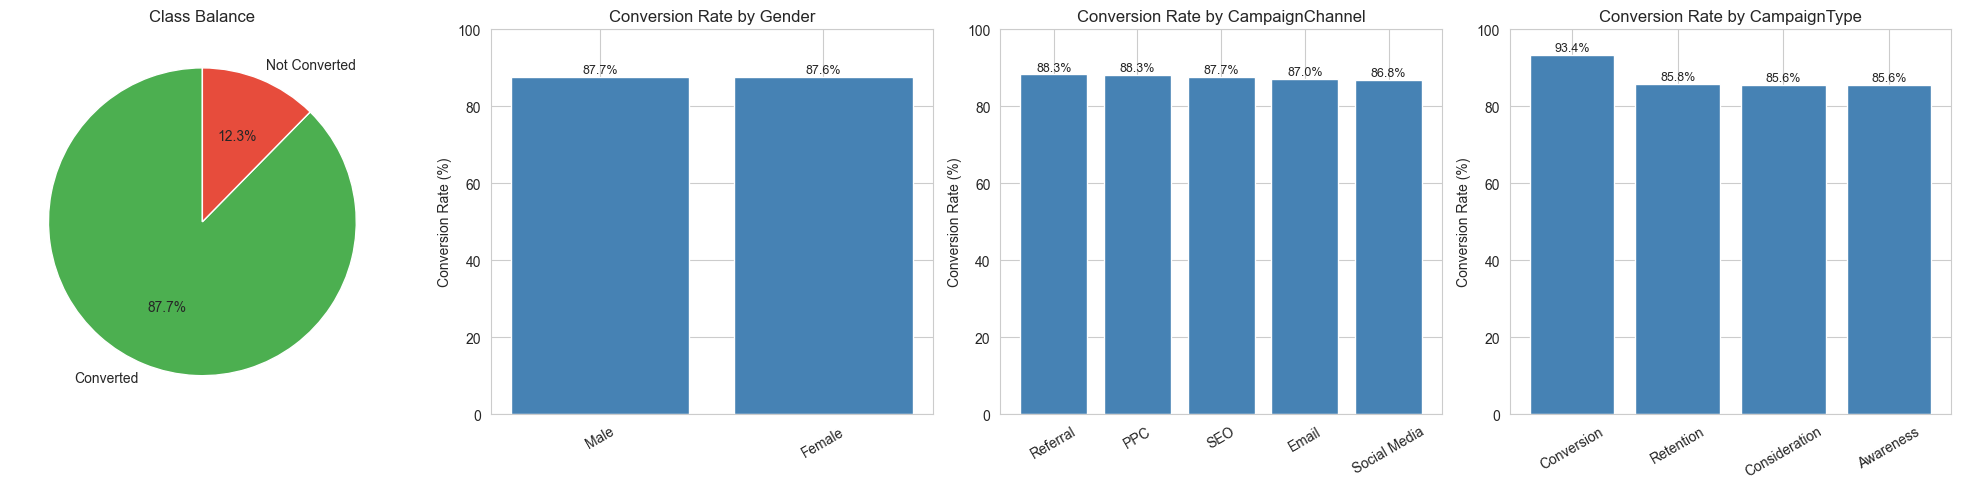

In [8]:
# Visualize class balance and conversion rate by category
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].pie(counts.values, labels=['Converted', 'Not Converted'],
            colors=['#4CAF50', '#E74C3C'], autopct='%.1f%%', startangle=90)
axes[0].set_title('Class Balance')

for ax, col in zip(axes[1:], ['Gender', 'CampaignChannel', 'CampaignType']):
    rates = df.groupby(col)['Conversion'].mean() * 100
    rates = rates.sort_values(ascending=False)
    ax.bar(rates.index, rates.values, color='steelblue', edgecolor='white')
    ax.set_title(f'Conversion Rate by {col}')
    ax.set_ylabel('Conversion Rate (%)')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(rates.values):
        ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**Key observations:**
- The target is heavily imbalanced (about 87.6% converted, 12.4% not converted). Lift will matter more than raw accuracy when evaluating models.
- Gender has no real effect on conversion rate.
- Channel matters very little (all five channels sit within roughly 1 percentage point of each other).
- Campaign Type matters a lot: "Conversion"-type campaigns convert about 93%, while Awareness and Consideration sit around 86%.

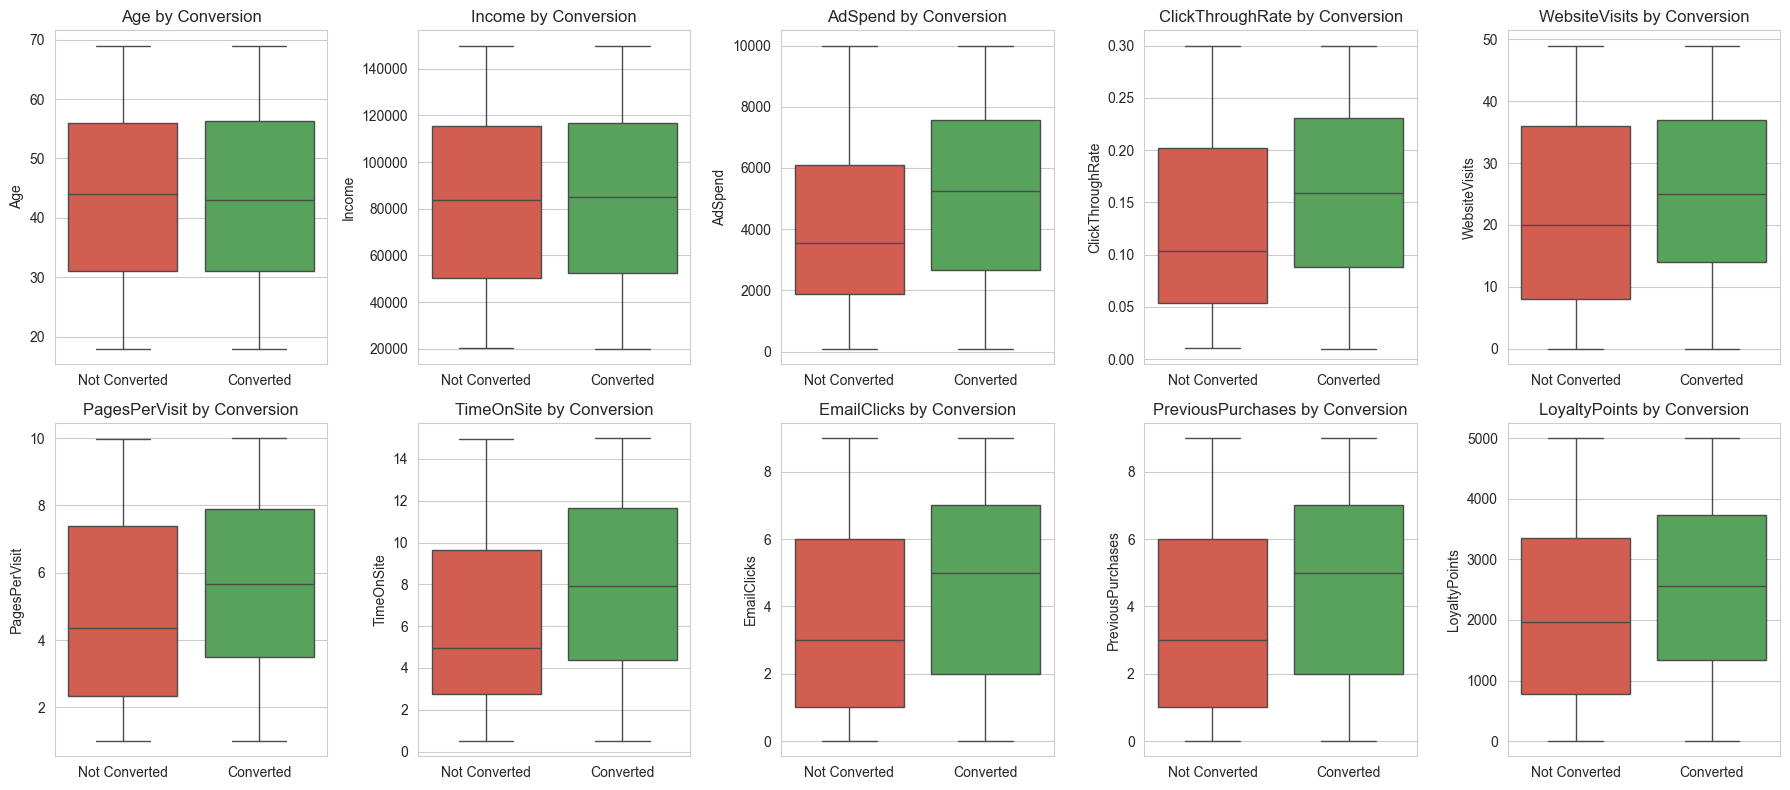

In [9]:
# How do numeric features differ between converters and non-converters?
boxplot_cols = ['Age', 'Income', 'AdSpend', 'ClickThroughRate',
                'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite',
                'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(boxplot_cols):
    sns.boxplot(data=df, x='Conversion', y=col, ax=axes[i],
                hue='Conversion', palette=['#E74C3C', '#4CAF50'], legend=False)
    axes[i].set_title(f'{col} by Conversion')
    axes[i].set_xlabel('')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Not Converted', 'Converted'])

plt.tight_layout()
plt.show()

In [10]:
# Mean of each numeric feature, split by Conversion
means = df.groupby('Conversion')[boxplot_cols].mean().T
means.columns = ['Not Converted', 'Converted']
means['Difference (%)'] = ((means['Converted'] - means['Not Converted'])
                            / means['Not Converted'] * 100).round(2)
means.round(2)

,Not Converted,Converted,Difference (%)
Age,43.56,43.63,0.17
Income,83265.31,84861.30,1.92
AdSpend,4058.40,5133.75,26.50
ClickThroughRate,0.13,0.16,23.94
WebsiteVisits,21.73,25.18,15.88
PagesPerVisit,4.84,5.65,16.86
TimeOnSite,6.27,7.93,26.57
EmailClicks,3.48,4.61,32.30
PreviousPurchases,3.63,4.61,27.06
LoyaltyPoints,2128.48,2541.24,19.39


Customers who convert spend more time on site, visit more pages, and have a higher click-through rate. Age and Income show almost no difference between the two groups, confirming that engagement matters more than demographics.

## 5. Correlation Analysis

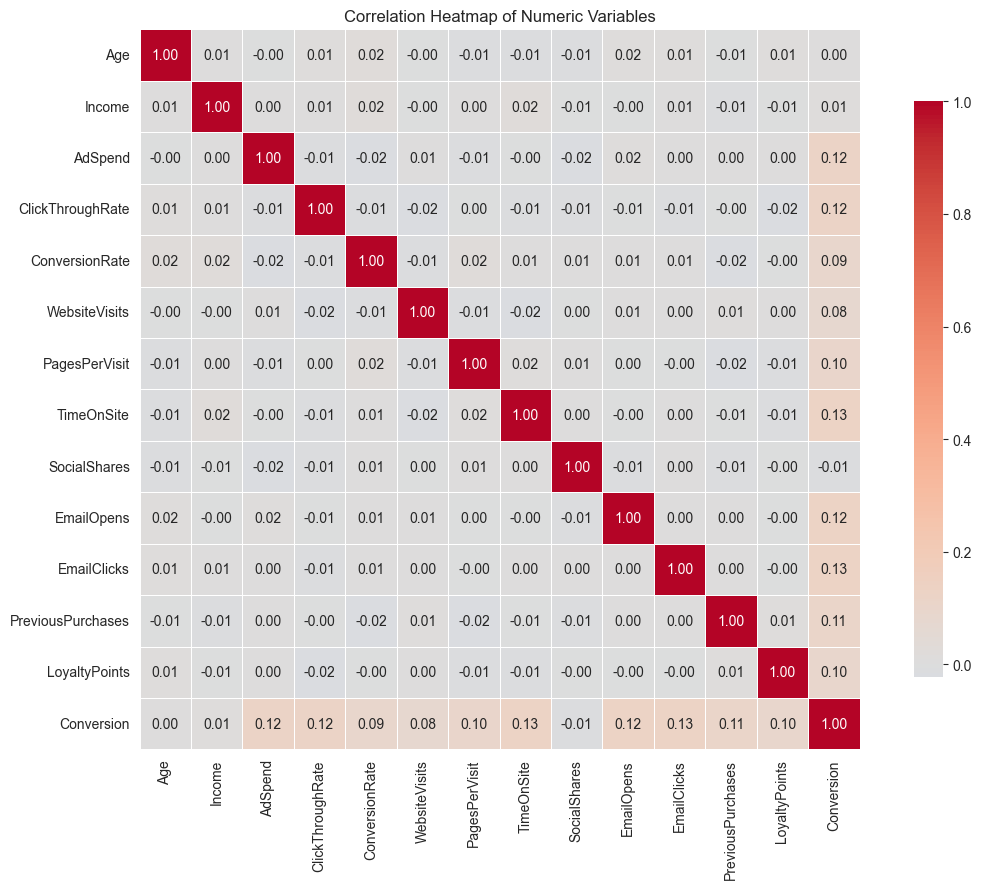

In [11]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

In [12]:
# Correlation with the conversion target only
target_corr = corr['Conversion'].drop('Conversion').sort_values(key=abs, ascending=False)
print('Correlation with Conversion (strongest first):')
print(target_corr.round(3).to_string())

Correlation with Conversion (strongest first):
TimeOnSite           0.130
EmailClicks          0.130
EmailOpens           0.125
AdSpend              0.125
ClickThroughRate     0.120
PreviousPurchases    0.112
PagesPerVisit        0.103
LoyaltyPoints        0.095
ConversionRate       0.093
WebsiteVisits        0.079
Income               0.014
SocialShares        -0.011
Age                  0.002


Individual correlations with the target are weak (all under 0.10 in absolute value). This is common in real marketing data: conversion depends on combinations of behaviors, not single variables. That's exactly what the next two sections (predictive modeling and association rules) will capture.

## 6. Predictive Modeling

Train three classifiers and compare them. The target is imbalanced, so we use `class_weight='balanced'` and look at ROC-AUC and per-class metrics in addition to overall accuracy.

In [13]:
# One-hot encode categorical variables
df_enc = pd.get_dummies(df, columns=['Gender', 'CampaignChannel', 'CampaignType'],
                        drop_first=True)

y = df_enc['Conversion']
X = df_enc.drop(columns=['Conversion'])

# Stratified train/test split keeps the class proportions the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

# Scale features for Logistic Regression (tree-based models don't need scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Test set:     {X_test.shape[0]} rows')

Training set: 6000 rows
Test set:     2000 rows


In [15]:
def evaluate_model(name, model, X_test_data, y_test):
    """Print accuracy, ROC-AUC, and classification report. Return prediction details."""
    y_pred = model.predict(X_test_data)
    y_proba = model.predict_proba(X_test_data)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f'\n--- {name} ---')
    print(f'Accuracy: {acc:.4f}')
    print(f'ROC-AUC:  {auc:.4f}')
    print('\nClassification report:')
    print(classification_report(y_test, y_pred,
                                 target_names=['Not Converted', 'Converted']))

    return {'model': name, 'accuracy': round(acc, 4), 'roc_auc': round(auc, 4),
            'y_pred': y_pred, 'y_proba': y_proba}

In [16]:
# Logistic Regression
logreg = LogisticRegression(max_iter=1000, class_weight='balanced',
                             random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
logreg_result = evaluate_model('Logistic Regression', logreg, X_test_scaled, y_test)


--- Logistic Regression ---
Accuracy: 0.7515
ROC-AUC:  0.7792

Classification report:
               precision    recall  f1-score   support

Not Converted       0.29      0.72      0.42       247
    Converted       0.95      0.76      0.84      1753

     accuracy                           0.75      2000
    macro avg       0.62      0.74      0.63      2000
 weighted avg       0.87      0.75      0.79      2000



In [17]:
# Decision Tree
tree = DecisionTreeClassifier(max_depth=5, class_weight='balanced',
                               random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
tree_result = evaluate_model('Decision Tree', tree, X_test, y_test)


--- Decision Tree ---
Accuracy: 0.7640
ROC-AUC:  0.7044

Classification report:
               precision    recall  f1-score   support

Not Converted       0.27      0.55      0.36       247
    Converted       0.93      0.79      0.86      1753

     accuracy                           0.76      2000
    macro avg       0.60      0.67      0.61      2000
 weighted avg       0.84      0.76      0.79      2000



In [18]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10,
                             class_weight='balanced',
                             random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_result = evaluate_model('Random Forest', rf, X_test, y_test)


--- Random Forest ---
Accuracy: 0.9020
ROC-AUC:  0.8072

Classification report:
               precision    recall  f1-score   support

Not Converted       0.87      0.24      0.38       247
    Converted       0.90      0.99      0.95      1753

     accuracy                           0.90      2000
    macro avg       0.89      0.62      0.66      2000
 weighted avg       0.90      0.90      0.88      2000



In [19]:
# Model comparison
results = [logreg_result, tree_result, rf_result]
summary = pd.DataFrame([{'model': r['model'], 'accuracy': r['accuracy'],
                          'roc_auc': r['roc_auc']} for r in results])
summary

,model,accuracy,roc_auc
0,Logistic Regression,0.7515,0.7792
1,Decision Tree,0.7640,0.7044
2,Random Forest,0.9020,0.8072


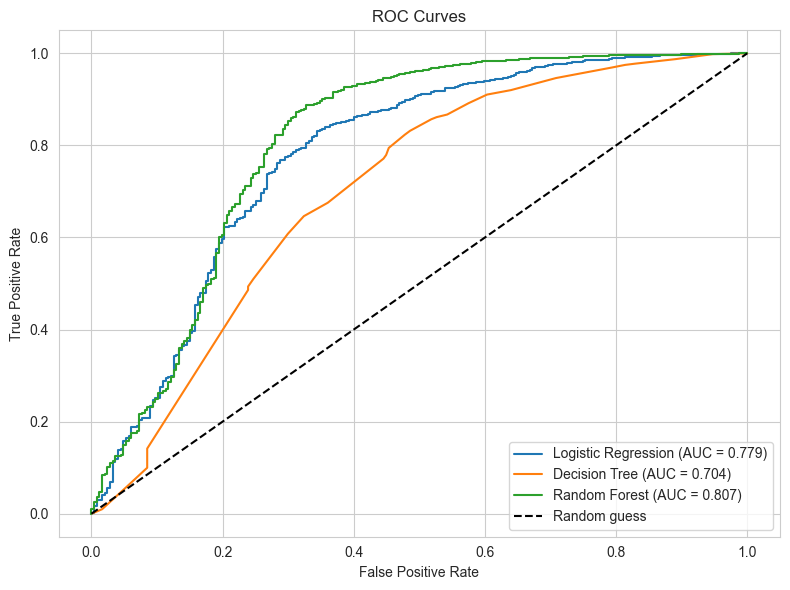

In [20]:
# ROC curves
plt.figure(figsize=(8, 6))
for r in results:
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    plt.plot(fpr, tpr, label=f"{r['model']} (AUC = {r['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.show()

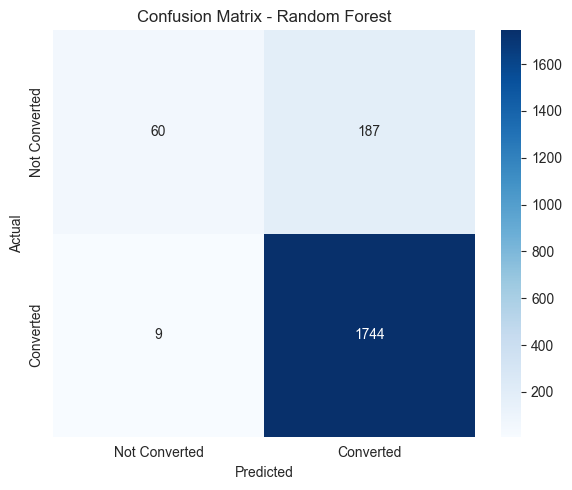

In [21]:
# Confusion matrix for the best model (Random Forest)
cm = confusion_matrix(y_test, rf.predict(X_test))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Converted', 'Converted'],
            yticklabels=['Not Converted', 'Converted'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

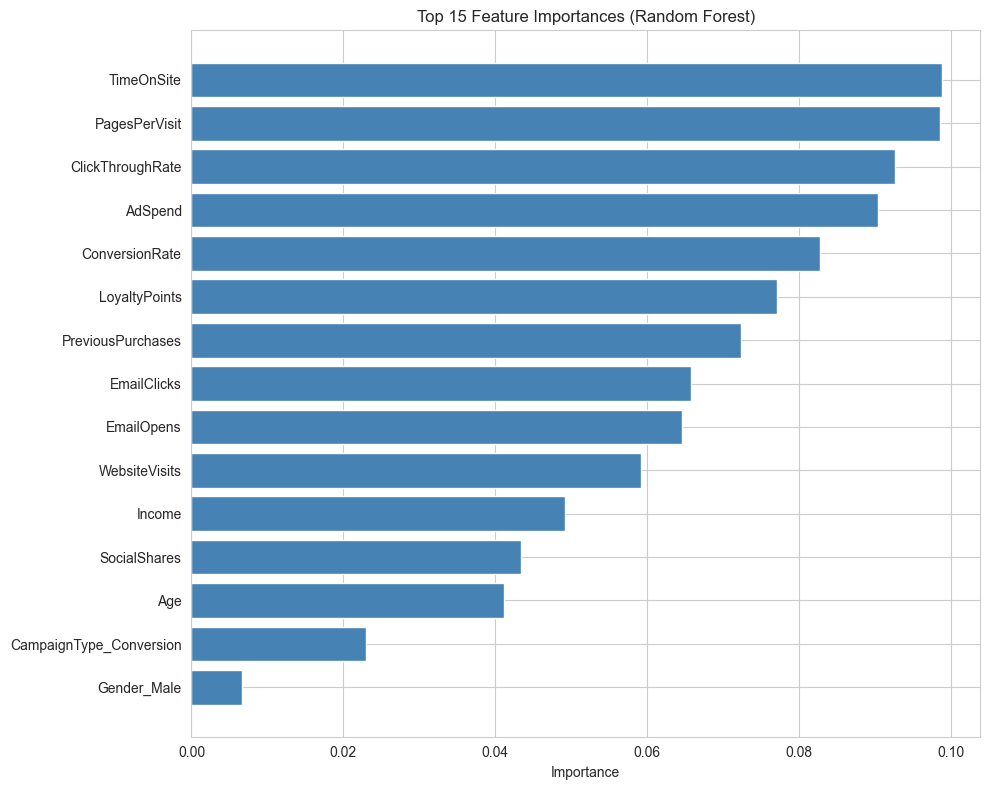

,feature,importance
7,TimeOnSite,0.098935
6,PagesPerVisit,0.098587
3,ClickThroughRate,0.092637
2,AdSpend,0.090489
4,ConversionRate,0.082818
12,LoyaltyPoints,0.077137
11,PreviousPurchases,0.072414
10,EmailClicks,0.065776
9,EmailOpens,0.064663
5,WebsiteVisits,0.059236


In [22]:
# Feature importance from Random Forest
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'][:15][::-1], importance['importance'][:15][::-1],
         color='steelblue')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

importance.head(10)

Random Forest is the strongest model on this dataset, with the highest accuracy and ROC-AUC. The top features driving conversion are all behavioral: time on site, pages per visit, click-through rate, and ad spend. Demographic variables (Gender, age groups) sit far lower in importance, matching what we saw in the EDA.

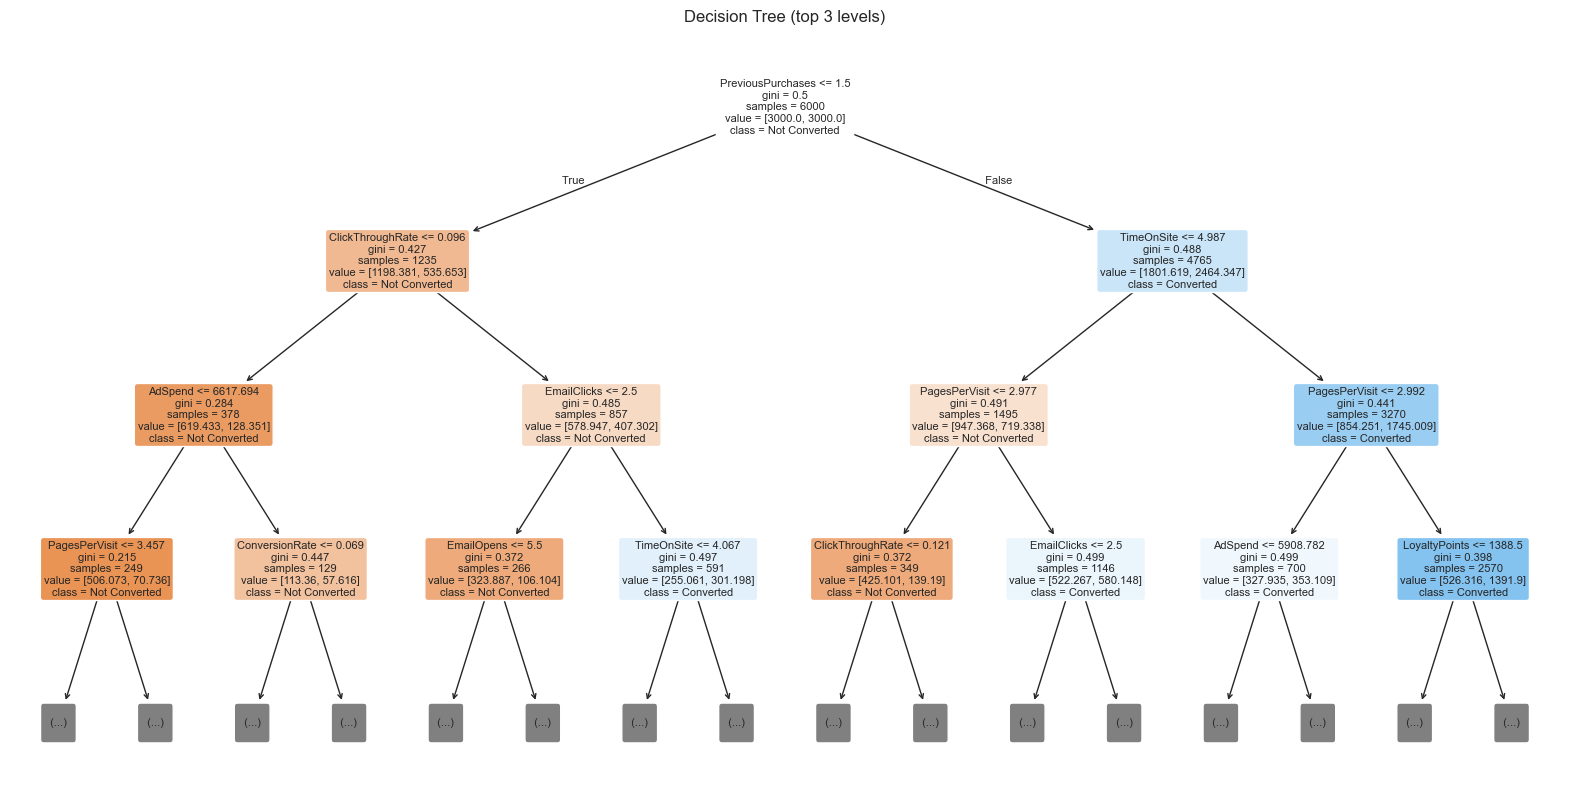

In [23]:
# Visualize the decision tree (top 3 levels only, for readability)
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X.columns,
          class_names=['Not Converted', 'Converted'],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title('Decision Tree (top 3 levels)')
plt.show()

## 7. Apriori Association Rule Mining

Apriori finds combinations of attribute values that frequently appear together. For our use case: which customer profiles are most strongly linked to converting?

**Step 1.** Discretize numeric variables into bins so they can be treated as items in a transaction.

**Step 2.** Convert each customer row into a transaction (a list of `attribute=value` items).

**Step 3.** Find frequent itemsets (support >= 5%) of size 1 through 4.

**Step 4.** Generate rules X -> Y with confidence >= 65% and evaluate by lift.

In [24]:
# Step 1 & 2: discretize numeric variables and build transactions
df_d = df.copy()

df_d['Age_bin']      = pd.cut(df_d['Age'], bins=[0, 30, 45, 60, 100],
                               labels=['Young', 'Middle', 'Senior', 'Elder'])
df_d['Income_bin']   = pd.cut(df_d['Income'], bins=3, labels=['Low', 'Medium', 'High'])
df_d['AdSpend_bin']  = pd.cut(df_d['AdSpend'], bins=3, labels=['Low', 'Medium', 'High'])
df_d['Loyalty_bin']  = pd.cut(df_d['LoyaltyPoints'], bins=3,
                               labels=['Bronze', 'Silver', 'Gold'])
df_d['Purchase_bin'] = pd.cut(df_d['PreviousPurchases'], bins=[-1, 2, 5, 10],
                               labels=['New', 'Regular', 'Loyal'])

# Build the transaction list
transactions = []
for _, row in df_d.iterrows():
    items = [
        f"Age={row['Age_bin']}",
        f"Income={row['Income_bin']}",
        f"AdSpend={row['AdSpend_bin']}",
        f"Loyalty={row['Loyalty_bin']}",
        f"Purchase={row['Purchase_bin']}",
        f"Channel={row['CampaignChannel']}",
        f"Type={row['CampaignType']}",
        f"Gender={row['Gender']}",
        'Converted' if row['Conversion'] == 1 else 'NotConverted',
    ]
    transactions.append(items)

print(f'Number of transactions: {len(transactions)}')
print(f'Example transaction:    {transactions[0]}')

Number of transactions: 8000
Example transaction:    ['Age=Senior', 'Income=High', 'AdSpend=Medium', 'Loyalty=Bronze', 'Purchase=Regular', 'Channel=Social Media', 'Type=Awareness', 'Gender=Female', 'Converted']


In [25]:
def get_frequent_itemsets(transactions, min_support):
    """Find frequent itemsets of size 1 to 4 with given minimum support.
    Returns dict of {frozenset(items): support}."""
    n = len(transactions)
    min_count = min_support * n

    # Count individual items
    item_counts = {}
    for t in transactions:
        for item in set(t):
            item_counts[item] = item_counts.get(item, 0) + 1

    # Keep frequent 1-itemsets
    L1 = {frozenset([item]): count / n
          for item, count in item_counts.items() if count >= min_count}
    print(f'Frequent 1-itemsets found: {len(L1)}')

    all_itemsets = dict(L1)
    current_L = L1

    # Generate itemsets of size 2, 3, 4
    for k in range(2, 5):
        if not current_L:
            break

        current_items = set()
        for itemset in current_L.keys():
            for item in itemset:
                current_items.add(item)

        candidates = set()
        for combo in combinations(current_items, k):
            candidates.add(frozenset(combo))

        Lk = {}
        for cand in candidates:
            count = sum(1 for t in transactions if cand.issubset(set(t)))
            if count >= min_count:
                Lk[cand] = count / n

        all_itemsets.update(Lk)
        current_L = Lk
        print(f'Frequent {k}-itemsets found: {len(Lk)}')

    return all_itemsets


frequent_itemsets = get_frequent_itemsets(transactions, min_support=0.05)
print(f'\nTotal frequent itemsets: {len(frequent_itemsets)}')

Frequent 1-itemsets found: 29
Frequent 2-itemsets found: 325
Frequent 3-itemsets found: 382
Frequent 4-itemsets found: 73

Total frequent itemsets: 809


In [28]:
def generate_rules(frequent_itemsets, min_confidence):
    """From frequent itemsets, build rules X -> Y with confidence >= threshold.
    Returns list of dicts with antecedent, consequent, support, confidence, lift."""
    rules = []
    for itemset, support in frequent_itemsets.items():
        if len(itemset) < 2:
            continue
        for i in range(1, len(itemset)):
            for antecedent in combinations(itemset, i):
                antecedent = frozenset(antecedent)
                consequent = itemset - antecedent

                antecedent_support = frequent_itemsets.get(antecedent)
                consequent_support = frequent_itemsets.get(consequent)
                if antecedent_support is None or consequent_support is None:
                    continue

                confidence = support / antecedent_support
                if confidence < min_confidence:
                    continue

                lift = confidence / consequent_support

                rules.append({
                    'antecedent': ', '.join(sorted(antecedent)),
                    'consequent': ', '.join(sorted(consequent)),
                    'support': round(support, 4),
                    'confidence': round(confidence, 4),
                    'lift': round(lift, 4),
                })
    return rules


rules = generate_rules(frequent_itemsets, min_confidence=0.65)
rules_df = pd.DataFrame(rules)
print(f'Total rules generated: {len(rules_df)}')

Total rules generated: 374


In [29]:
# Keep only rules that predict Converted (the outcome of interest)
rules_to_conv = rules_df[rules_df['consequent'] == 'Converted'].copy()
rules_to_conv = rules_to_conv.sort_values('lift', ascending=False)

print(f'Rules predicting Converted: {len(rules_to_conv)}')
print('\nTop 10 rules by lift:')
rules_to_conv.head(10)

Rules predicting Converted: 372

Top 10 rules by lift:


,antecedent,consequent,support,confidence,lift
65,"Purchase=Regular, Type=Conversion",Converted,0.0745,0.9613,1.0967
331,"AdSpend=High, Gender=Female, Type=Conversion",Converted,0.0522,0.9587,1.0938
323,"AdSpend=High, Gender=Female, Purchase=Loyal",Converted,0.0755,0.9557,1.0904
66,"Loyalty=Gold, Type=Conversion",Converted,0.0803,0.9554,1.0900
371,"Gender=Female, Loyalty=Silver, Type=Conversion",Converted,0.0535,0.9532,1.0875
337,"AdSpend=High, Gender=Female, Purchase=Regular",Converted,0.0554,0.9527,1.0869
372,"AdSpend=High, Gender=Female, Loyalty=Gold",Converted,0.0596,0.9521,1.0862
249,"AdSpend=High, Type=Conversion",Converted,0.0826,0.9511,1.0851
301,"Gender=Female, Purchase=Loyal, Type=Conversion",Converted,0.0648,0.9505,1.0844
272,"Age=Middle, Type=Conversion",Converted,0.0719,0.9473,1.0808


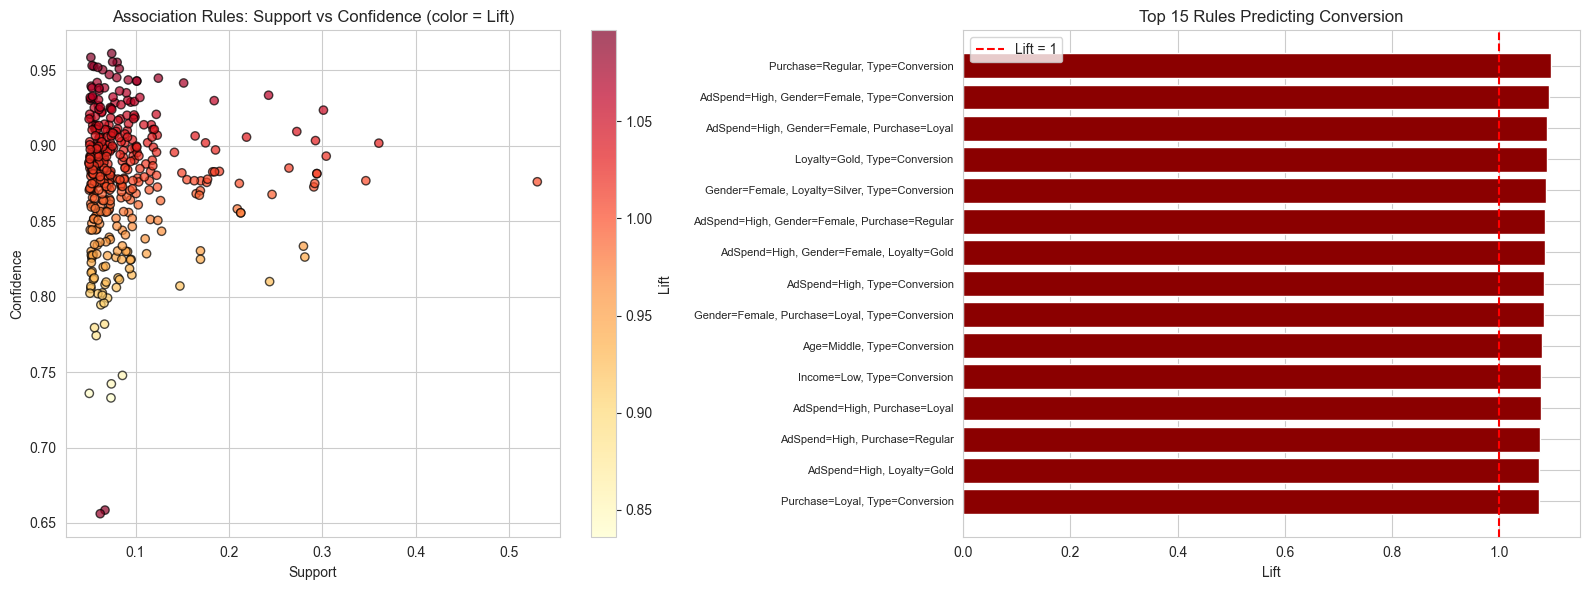

In [30]:
# Visualize: support vs confidence (colored by lift), and top 15 rules
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter = axes[0].scatter(rules_df['support'], rules_df['confidence'],
                           c=rules_df['lift'], cmap='YlOrRd',
                           alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Association Rules: Support vs Confidence (color = Lift)')
plt.colorbar(scatter, ax=axes[0], label='Lift')

top = rules_to_conv.head(15).iloc[::-1]
axes[1].barh(range(len(top)), top['lift'], color='darkred')
axes[1].set_yticks(range(len(top)))
axes[1].set_yticklabels([a[:60] + '...' if len(a) > 60 else a
                          for a in top['antecedent']], fontsize=8)
axes[1].axvline(1.0, color='red', linestyle='--', label='Lift = 1')
axes[1].set_xlabel('Lift')
axes[1].set_title('Top 15 Rules Predicting Conversion')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Key Findings

**Engagement beats demographics.** The strongest predictors of conversion are behavioral: time on site, pages per visit, click-through rate, and ad spend. Age and income show almost no predictive power.

**Campaign type matters more than channel.** "Conversion"-type campaigns convert about 93% of the time, while the other types (Awareness, Consideration, Retention) all sit near 86%. Channel (Email, SEO, Social Media, PPC, Referral) has essentially no effect on conversion rate. Apriori confirmed this: channel did not appear in any of the top rules.

**Strongest customer profile.** Combinations of high ad spend + female + Conversion-type campaign show 95-96% confidence and the highest lift values in association rule mining.

**Recommendations:**
1. Build a real-time lead scoring system to flag users once they cross thresholds of ~8 minutes time on site, ~4-5 email clicks, or ~25 website visits.
2. Shift focus from channel optimization to campaign-message optimization.
3. Reward high-volume historical buyers with an early-access or VIP program.
4. Run A/B tests on site UI changes aimed at closing the engagement-duration gap between converters and non-converters.